# Sin-wave Generation

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [64]:
def normalize(
    array: np.array,
    min_: float = None,
    max_: float = None
):
    if len(np.unique(array)) == 1:
        value = np.unique(array)[0]
        norm_value = 0.5
        if max_ != min_:
            norm_value = (value - min_) / (max_ - min_)
        return np.ones_like(array) * norm_value
    if min_ is None:
        min_ = array.min()
    if max_ is None:
        max_ = array.max()
    return (array - min_) / (max_ - min_)

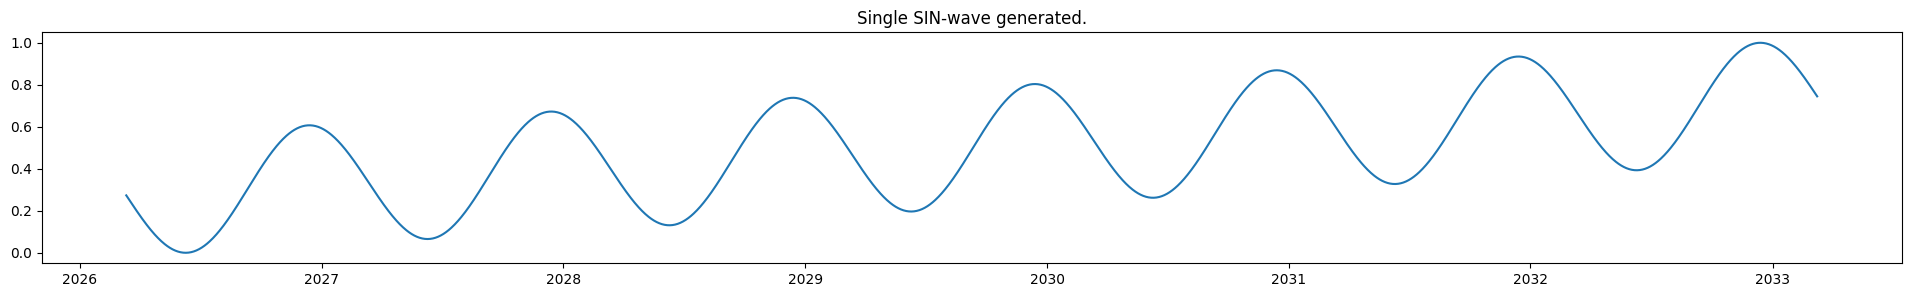

In [65]:
n_years = np.random.randint(1, 15)
frequency = 2 * np.pi / 365.25

beta = 1
elevation_power = 0
amplitude_change_power = 0
variation = True

amplitude = np.random.randint(-100, 100)
phase_shift = np.random.randint(-180, 180)
period_starts = pd.Timestamp('now')
a = np.random.randint(-500, 500) / (n_years * 365.25)
b = np.random.randint(-100, 100)

duration_days = 365 * n_years
period_ends = period_starts + pd.Timedelta(days=duration_days)

x = np.linspace(1, duration_days, duration_days)

if not variation:
    y = amplitude * np.sin(frequency * x + phase_shift)
else:
    y = amplitude * (x**amplitude_change_power) * np.sin(x**beta * frequency + phase_shift)

y += a * x + b
y += -1 + x**elevation_power
x_date = pd.date_range(period_starts, period_ends, freq='D')[:-1]
y = normalize(y)


plt.figure(figsize=(24,3))
plt.plot(x_date, y)
plt.title('Single SIN-wave generated.')
plt.show()
x_train, x_test, y_train, y_test = train_test_split(x.reshape(-1,1), y, shuffle=False)

# Torch

## Eliminate Linear

In [5]:
import torch
import tqdm


In [7]:
def torch_least_squares_simple(x, y) -> tuple:
    '''
    Both x and y are 1D arrays
    returns (a, b) from y = ax + b
    '''
    n = len(x)
    sum_x = torch.sum(x)
    sum_y = torch.sum(y)
    sum_xy = torch.sum(x * y)
    sum_x2 = torch.sum(x**2)
    denominator = n * sum_x2 - sum_x**2
    a = (n * sum_xy - sum_x * sum_y) / denominator
    b = (sum_y * sum_x2 - sum_x * sum_xy) / denominator
    return a, b
    

/tmp/ipykernel_1268930/624248865.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = a * x + b


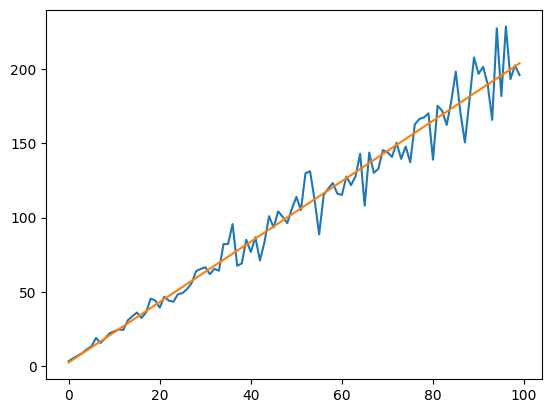

In [ ]:
import numpy as np
x = np.arange(100) / 1
y = 2*x + 3
noise_level = 0.1
y *= 1 + noise_level * np.random.randn(len(y))

a, b = torch_least_squares_simple(torch.tensor(x), torch.tensor(y))
y_pred = a.item() * x + b.item()
plt.plot(x, y)
plt.plot(x, y_pred)

In [ ]:

class SineNN(torch.nn.Module):
    def __init__(self, y):
        super().__init__()
        device = y.device
        self.a = torch.nn.Parameter(torch.tensor(200., device=device))
        self.b = torch.nn.Parameter(torch.tensor(1., device=device))
        self.c = torch.nn.Parameter(torch.tensor(0.5, device=device))
        
    def forward(self, x):
        return self.a * torch.sin(x + self.b) + self.c

device = "cuda"
x_train = torch.tensor(x_train, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train, dtype=torch.float32, device=device)

model = SineNN(y_train).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1)

for _ in tqdm.tqdm(range(1000)):
    optimizer.zero_grad()
    (loss := torch.mean((model(x_train) - y_train)**2)).backward()
    optimizer.step()

print(model.a.item(), model.b.item(), model.c.item())


x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)
y_pred = model(x_test_tensor).detach().cpu().numpy()

/tmp/ipykernel_17362/2902515541.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32, device=device)
/tmp/ipykernel_17362/2902515541.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32, device=device)
100%|██████████| 1000/1000 [00:00<00:00, 1454.01it/s]

8.91636864253087e-06 1.25653076171875 0.4340512752532959


In [87]:
class SineNN_FFT(torch.nn.Module):
    def __init__(self, y):
        super().__init__()
        device = y.device
        
        N = y.shape[0]
        Yf = torch.fft.fft(y)
        freqs = torch.fft.fftfreq(N)
        mag = torch.abs(Yf[:N//2])
        peak_idx = torch.argmax(mag[1:]) + 1
        
        ampl0 = 2 * mag[peak_idx] / N
        phase0 = torch.angle(Yf[peak_idx])
        c0 = y.mean()
        
        self.a = torch.nn.Parameter(torch.tensor(ampl0, device=device))
        self.b = torch.nn.Parameter(torch.tensor(phase0, device=device))
        self.c = torch.nn.Parameter(torch.tensor(c0, device=device))
        
    def forward(self, x):
        return self.a * torch.sin(x + self.b) + self.c

In [91]:
model = SineNN_FFT(y_train).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for _ in tqdm.tqdm(range(1000)):
    optimizer.zero_grad()
    (loss := torch.mean((model(x_train) - y_train)**2)).backward()
    optimizer.step()

print(model.a.item(), model.b.item(), model.c.item())


x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)
y_pred = model(x_test_tensor).detach().cpu().numpy()

/tmp/ipykernel_17362/3626896740.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.a = torch.nn.Parameter(torch.tensor(ampl0, device=device))
/tmp/ipykernel_17362/3626896740.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.b = torch.nn.Parameter(torch.tensor(phase0, device=device))
/tmp/ipykernel_17362/3626896740.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.c = torch.nn.Parameter(torch.tensor(c0, device=device))
100%|██████████| 1000/1000 [00:00<00:00, 1563.63it/s]

2.252071863040328e-05 2.1276752948760986 0.4340513050556183


In [ ]:
class FFTPredictor:
    def __init__(self, y: torch.Tensor):
        """
        y: 1D tensor (float32) signal to analyze
        Computes amplitude, phase, and offset from FFT
        """
        N = y.shape[0]

        Yf = torch.fft.fft(y)
        mag = torch.abs(Yf[:N//2])
        peak_idx = torch.argmax(mag[1:]) + 1  # skip DC

        self.ampl = 2 * mag[peak_idx] / N
        self.phase = torch.angle(Yf[peak_idx])
        self.offset = y.mean()

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: input tensor of positions
        Returns predicted sine values using FFT-estimated parameters
        """
        return self.ampl * torch.sin(x + self.phase) + self.offset

In [98]:
torch.fft.fft(y_train_tensor)

tensor([831.6422+0.0000j, -16.7095+108.0916j, -18.8377+59.8880j,
         ..., -23.9169-49.2210j, -18.8377-59.8880j,
        -16.7095-108.0916j], device='cuda:0')

In [95]:
device = "cuda"
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)

fft_pred = FFTPredictor(y_train_tensor)
y_pred = fft_pred.predict(x_test_tensor)

/tmp/ipykernel_17362/231372252.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
/tmp/ipykernel_17362/231372252.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)


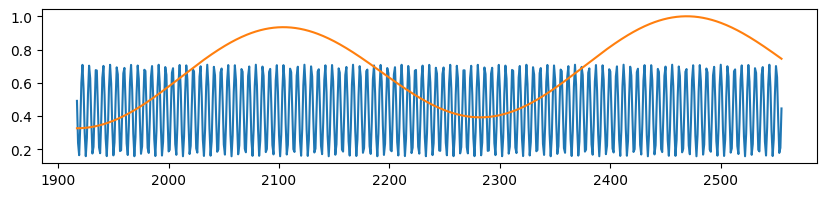

In [97]:
plt.figure(figsize=(10, 2))
plt.plot(x_test, y_pred.cpu().detach().numpy())
plt.plot(x_test, y_test)